## load data

In [171]:
import pandas as pd

df = pd.read_csv('train1.csv', index_col=None)

In [172]:
datasets = [     'election2020',   'covid_political', 'ukr_rus_suspended',
   'ukr_rus_twitter',           'midterm',   'covid19_twitter']
ds_pat = "|".join(datasets)
task_pat = "nm|lp|pl"
pat = f'eval_({ds_pat})_({task_pat})_to_({ds_pat})_({task_pat})_\d+shot'
df[['train1_dataset', 'train1_task', 'eval_dataset', 'eval_task']] = df.display_name.str.extract(pat)

## plots

In [173]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# DATASETS = ['covid19_twitter', 'ukr_rus_twitter', 'midterm']
DATASETS = [     'election2020',   'covid_political', 'ukr_rus_suspended','ukr_rus_twitter',           'midterm',   'covid19_twitter']
EVAL_TASKS = ["nm", "lp", "pl"]
colors = {"nm": "#00b4d8", "lp": "#f72585", "pl": "#80b918"}

fig = make_subplots(
    rows=len(DATASETS),
    cols=len(EVAL_TASKS),
    shared_yaxes=True,
    subplot_titles=[
        f"{ds} | {t.upper()}"
        for ds in DATASETS for t in EVAL_TASKS
    ],
)

seen = set()

for row, DATASET in enumerate(DATASETS, start=1):
    # slice once per dataset
    i_cross = df.train1_dataset.eq(DATASET) & df.eval_dataset.eq(DATASET)
    plot_df_cross = df[i_cross].copy()

    i_same = (
        df.train1_dataset.eq(DATASET)
        & df.eval_dataset.eq(DATASET)
    )
    plot_df_same = df[i_same].copy()

    for col, eval_task in enumerate(EVAL_TASKS, start=1):
        # --- Cross ---
        sub_c = plot_df_cross[plot_df_cross["eval_task"] == eval_task]
        for tt in sorted(sub_c["train1_task"].dropna().unique()):
            s = sub_c[sub_c["train1_task"] == tt] \
                .sort_values("shot_label") \
                .dropna(subset=["test_roc_auc"])

            s.loc[s.test_roc_auc.lt(0.5), 'test_roc_auc'] = 0.5 + (0.5 - s.test_roc_auc)

            name = tt.upper()
            fig.add_trace(go.Scatter(
                x=s["shot_label"], y=s["test_roc_auc"],
                mode="lines+markers",
                name=name,
                legendgroup=name,
                showlegend=name not in seen,
                line=dict(color=colors.get(tt)),
                customdata=s[["display_name", "pretrained_model_run", 'steps']].values,
                hovertemplate="<b>%{customdata[1]}</b><br>shots=%{x}<br>AUC=%{y:.3f}<br>train_steps=%{customdata[2]}<br>%{customdata[0]}<extra></extra>",
            ), row=row, col=col)
            seen.add(name)

        # --- Baseline ---
        sub_s = plot_df_same[plot_df_same["eval_task"] == eval_task]
        for tt in sorted(sub_s["train1_task"].dropna().unique()):
            s = sub_s[sub_s["train1_task"] == tt] \
                .sort_values("shot_label") \
                .dropna(subset=["test_roc_auc"])

            name = f"{tt.upper()} (baseline)"
            fig.add_trace(go.Scatter(
                x=s["shot_label"], y=s["test_roc_auc"],
                mode="lines+markers",
                name=name,
                legendgroup=name,
                showlegend=name not in seen,
                line=dict(color=colors.get(tt), dash="dash"),
                opacity=0.5,
                customdata=s[["display_name", "pretrained_model_run", 'steps']].values,
                hovertemplate="<b>%{customdata[1]}</b><br>shots=%{x}<br>AUC=%{y:.3f}<br>train_steps=%{customdata[2]}<br>%{customdata[0]}<extra></extra>",
            ), row=row, col=col)
            seen.add(name)

        fig.update_xaxes(title_text="Shots", row=row, col=col)

# only leftmost y-axis labeled
for r in range(1, len(DATASETS)+1):
    fig.update_yaxes(title_text="ROC-AUC" if r == 1 else "", row=r, col=1)

fig.update_layout(
    height=300 * len(DATASETS),
    width=350 * len(EVAL_TASKS),
    legend=dict(orientation="h", y=-0.1, x=0.5, xanchor="center"),
    hovermode="closest",
)

fig.show()

In [174]:
df['seq_'] = df.seq.str.replace("\(\d+\)", "", regex=True)
df['eval_id_'] = df.eval_id.str.replace("\(\d+\)", "", regex=True)
df['train_id_'] = df.train_id.str.replace("\(\d+\)", "", regex=True)
# mat_df = df.sort_values('auc', ascending=False).drop_duplicates(subset=['seq_'])[['train_id', 'eval_id_', 'auc']]

In [175]:
mat_df = df.groupby(['train_id_', 'train_id', 'eval_id', 'eval_id_']).auc.max().groupby(['train_id_', 'train_id', 'eval_id_']).mean().reset_index().sort_values('auc', ascending=False).drop_duplicates(['train_id_', 'eval_id_'])

In [176]:
# mat_df = df.loc[df.groupby(['train_id', 'eval_id_']).auc.idxmax()]
mat_df = df[df.n_shots.eq(10)]

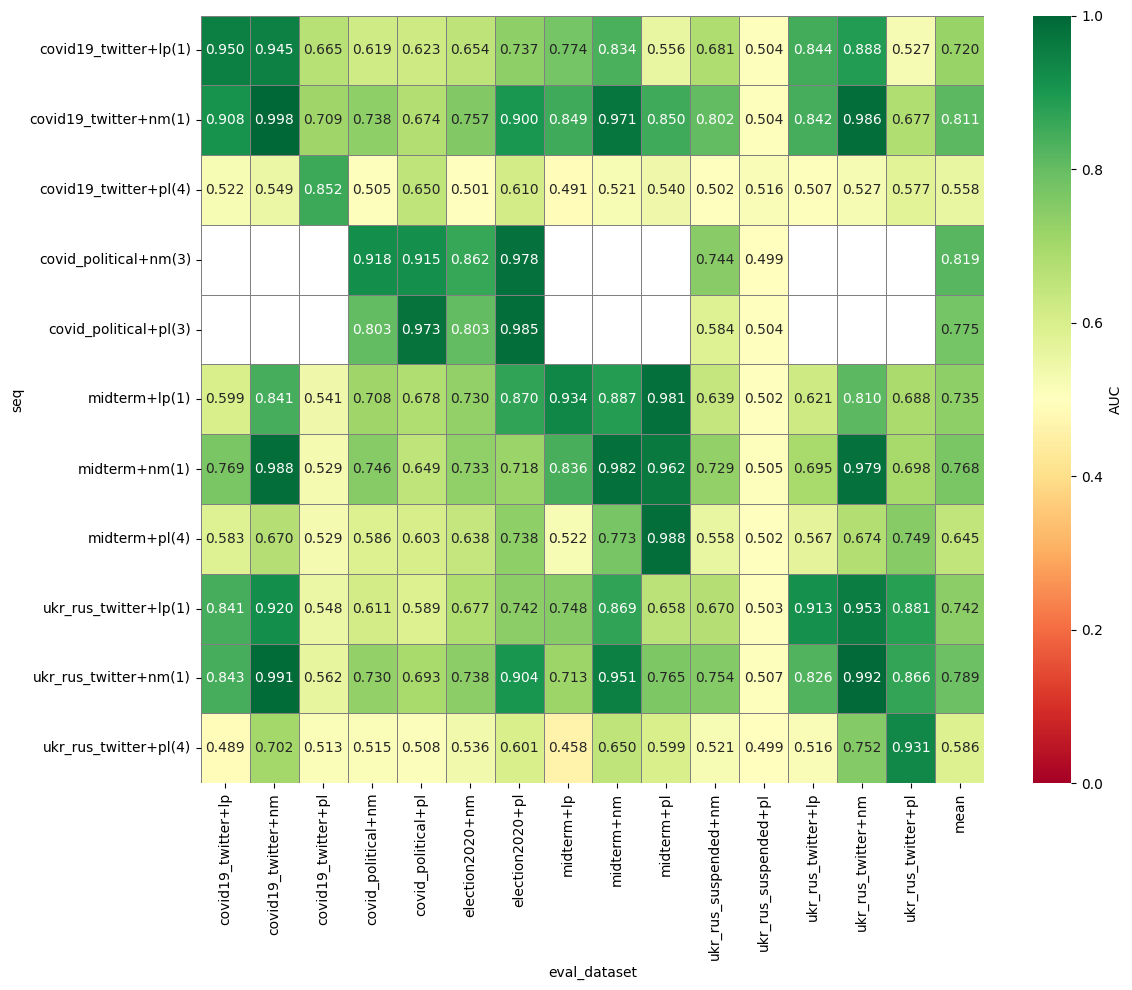

In [178]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# pivot to matrix: rows=seq, cols=eval_dataset
mat = mat_df.pivot_table(
    index="train_id",
    columns="eval_id_",
    values="auc",
    # aggfunc="mean"   # or max/min depending on meaning
)

mat["mean"] = mat.mean(axis=1)

# plot
plt.figure(figsize=(12,10))
sns.heatmap(
    mat,
    cmap="RdYlGn",
    vmin=0, vmax=1,
    annot=True,        # show values
    fmt=".3f",         # 3 decimal places
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"label": "AUC"}
)

plt.ylabel("seq")
plt.xlabel("eval_dataset")
plt.tight_layout()
plt.show()